# Brouillon : toutes les transformations, sur un marché jouet

Ce notebook ne lit **aucune donnée** du challenge. Il invente un petit marché, avec 4 titres et 8 jours, puis applique une à une
les transformations du papier, chacune avec une figure simple. Tout tourne en quelques secondes sur CPU.

| § | Transformation | Idée en une phrase |
|---|---|---|
| 1 | Le marché jouet | 2 titres à gros tick, 2 à petit tick ; chaque jour a son propre régime de profondeur |
| 2 | Unités naturelles | En ticks et en lots, les titres se distinguent ; divisés par une médiane locale, ils se ressemblent |
| 3 | Rang de première apparition | L'identifiant d'ordre ne garde que « même ordre ou non » |
| 4 | Parcours d'ordres | Occurrence, action précédente du même ordre, écart |
| 5 | Tokens | Chaque événement devient 11 petits entiers |
| 6 | Statistiques de fenêtre | Une ligne par fenêtre : spread, lots, profondeur… |
| 7 | Le piège du régime | Utile *et* décalé : la profondeur |
| 8 | Validation aléatoire vs par jour | Pourquoi 0,87 en validation et 0,50 au test |
| 9 | Augmentation de profondeur | Apprendre qu'un titre peut afficher plus ou moins d'actions |
| 10 | Sinkhorn | Rééquilibrer les prédictions entre titres |
| 11 | Vote entre voisins | Les fenêtres semblables votent ensemble |
| 12 | Pseudo-labels | Filtre d'accord + quota par titre, contre un simple seuil |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': .25, 'font.size': 9, 'axes.titleweight': 'bold'})
COL = ['#2a6fdb', '#1f9e89', '#e07b39', '#c94f4f']          # une couleur par titre
TICK, LOT, L = 0.01, 100, 40                                # tick de prix, lot, événements par fenêtre
rng = np.random.default_rng(0)

## 1. Le marché jouet

Quatre titres, chacun avec une **signature** fixe :
- **titres 0 et 1** : gros tick, le spread vaut presque toujours 1 tick, et les ordres sont en lots ronds (multiples de 100) ;
- **titres 2 et 3** : petit tick, le spread vaut plusieurs ticks, et il y a beaucoup d'odd lots.

Les deux titres d'une même famille se ressemblent beaucoup, et ont la même profondeur *en moyenne*. Chaque **jour**, et même chaque **titre-jour**, ajoute un **régime** : un niveau de profondeur du carnet. Les jours 0 à 5 forment le train, les jours 6 et 7 le
« test », et ils sont **moins profonds**, comme dans le vrai challenge. Un jour donne 10 fenêtres par titre.

In [2]:
STOCKS = {  # spread typique (ticks), part d'odd lots, profondeur de base (actions)
    0: dict(spread=[1, 1, 1, 2], odd=.08, depth=2000),
    1: dict(spread=[1, 1, 1, 2, 2], odd=.12, depth=2000),
    2: dict(spread=[3, 5, 8, 12], odd=.45, depth=900),
    3: dict(spread=[3, 5, 7, 10], odd=.40, depth=900),
}
DAYS = 8
day_depth = np.exp(rng.normal(0, .35, DAYS)); day_depth[6:] *= .55      # les jours « test » sont moins profonds
stock_day = np.exp(rng.normal(0, .5, (4, DAYS)))                         # chaque titre-jour a en plus son propre régime

def make_window(stock, day, obs_id):
    s = STOCKS[stock]
    rows, live = [], []                       # live : ordres présents dans le carnet
    mid = 100 + rng.normal(0, 2)
    for t in range(L):
        spread = rng.choice(s['spread'])
        bid, ask = mid - spread * TICK / 2, mid + spread * TICK / 2
        act = rng.choice(['A', 'D', 'U'], p=[.5, .4, .1]) if live else 'A'
        if act == 'A':
            oid = int(rng.integers(10**6, 10**7)); live.append(oid)     # identifiant anonymisé, valeur arbitraire
        else:
            oid = int(rng.choice(live))
            if act == 'D': live.remove(oid)
        side = rng.choice(['B', 'S'])
        dist = int(rng.choice([0, 0, 1, 2, 4]))                          # ticks derrière le meilleur prix
        price = (bid - dist * TICK) if side == 'B' else (ask + dist * TICK)
        size = int(rng.integers(1, 30)) if rng.random() < s['odd'] else LOT * int(rng.integers(1, 6))
        depth = s['depth'] * day_depth[day] * stock_day[stock, day]
        rows.append(dict(obs_id=obs_id, stock=stock, day=day, t=t, order_id=oid, action=act, side=side,
                         price=round(price, 4), bid=round(bid, 4), ask=round(ask, 4),
                         bid_size=int(depth * rng.lognormal(0, .3)), ask_size=int(depth * rng.lognormal(0, .3)),
                         flux=size if act == 'A' else -size if act == 'D' else 0))
        if rng.random() < .1: mid += rng.choice([-1, 1]) * TICK
    return rows

rows, obs = [], 0
for day in range(DAYS):
    for stock in STOCKS:
        for _ in range(10):
            rows += make_window(stock, day, obs); obs += 1
X = pd.DataFrame(rows)
X.loc[rng.random(len(X)) < .03, 'order_id'] = np.nan        # quelques identifiants manquants, comme dans les vraies données
print(f'{X.obs_id.nunique()} fenêtres de {L} événements, {len(X):,} lignes')
X.head(8)

320 fenêtres de 40 événements, 12,800 lignes


,obs_id,stock,day,t,order_id,action,side,price,bid,ask,bid_size,ask_size,flux
0,0,0,0,0,3896824.0,A,S,97.4969,97.4769,97.4869,1337,2276,400
1,0,0,0,1,4394250.0,A,S,97.4969,97.4769,97.4869,1468,1790,400
2,0,0,0,2,2352515.0,A,S,97.5069,97.4769,97.4869,1289,1034,400
3,0,0,0,3,6222991.0,A,S,97.4969,97.4669,97.4769,1777,758,400
4,0,0,0,4,4394250.0,U,B,97.4519,97.4619,97.4819,1746,2539,0
5,0,0,0,5,9540493.0,A,S,97.4969,97.4669,97.4769,1215,1312,300
6,0,0,0,6,9540493.0,D,S,97.4769,97.4669,97.4769,1172,2440,-100
7,0,0,0,7,6222991.0,U,S,97.4719,97.4519,97.4719,1542,1233,0


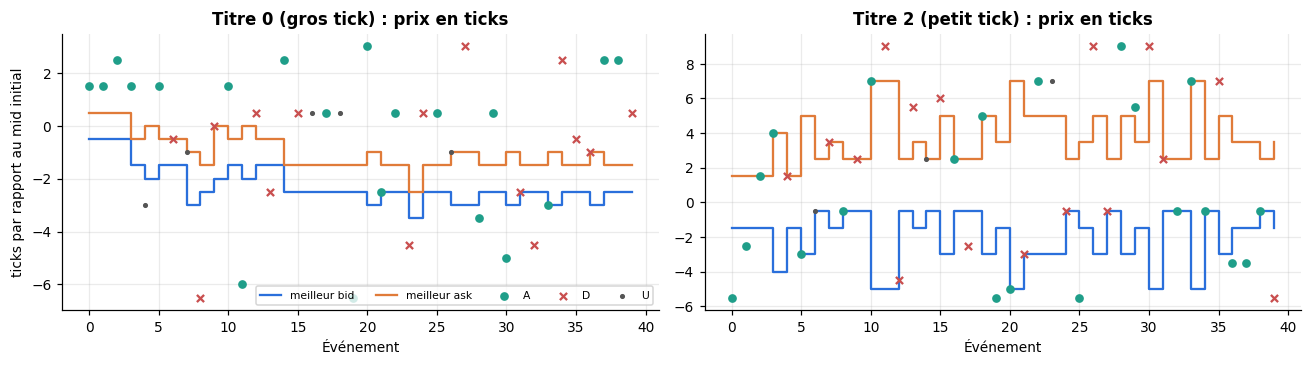

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), sharey=False)
for ax, stock in zip(axs, [0, 2]):
    w = X[(X.stock == stock)].query('obs_id == obs_id.min()')
    ref = (w.bid.iloc[0] + w.ask.iloc[0]) / 2
    ax.step(w.t, (w.bid - ref) / TICK, where='post', color='#2a6fdb', label='meilleur bid')
    ax.step(w.t, (w.ask - ref) / TICK, where='post', color='#e07b39', label='meilleur ask')
    for a, m, c in [('A', 'o', '#1f9e89'), ('D', 'x', '#c94f4f'), ('U', '.', '#555')]:
        e = w[w.action == a]; ax.scatter(e.t, (e.price - ref) / TICK, marker=m, color=c, s=22, label=f'{a}', zorder=3)
    ax.set_title(f'Titre {stock} ({"gros" if stock < 2 else "petit"} tick) : prix en ticks'); ax.set_xlabel('Événement')
axs[0].set_ylabel('ticks par rapport au mid initial'); axs[0].legend(fontsize=7, ncol=5)
plt.tight_layout()

## 2. Unités naturelles : ticks et lots

L'ancienne approche divisait le spread par sa **médiane locale** dans la fenêtre. Un titre dont le spread vaut toujours 1 tick
et un titre dont le spread vaut toujours 6 ticks donnent alors **la même valeur**, 1. La signature du titre disparaît.
En **ticks**, au contraire, les deux familles se séparent nettement.

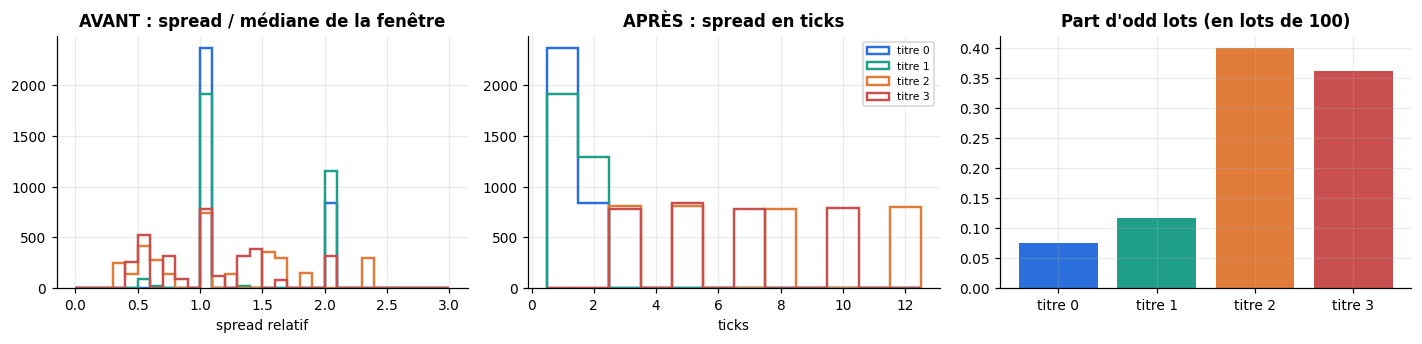

In [4]:
X['spread_t'] = ((X.ask - X.bid) / TICK).round().astype(int)          # spread en ticks : un entier
X['size_lots'] = X.flux.abs() / LOT                                    # taille en lots
X['odd'] = (X.flux.abs() % LOT != 0) & (X.flux != 0)                   # odd lot : pas un multiple de 100
med = X.groupby('obs_id').spread_t.transform('median')
X['spread_rel'] = X.spread_t / med                                     # ancienne normalisation par médiane locale

fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
for s in STOCKS:
    g = X[X.stock == s]
    axs[0].hist(g.spread_rel, bins=np.linspace(0, 3, 31), histtype='step', lw=1.6, color=COL[s], label=f'titre {s}')
    axs[1].hist(g.spread_t, bins=np.arange(0.5, 13.5), histtype='step', lw=1.6, color=COL[s], label=f'titre {s}')
axs[0].set_title('AVANT : spread / médiane de la fenêtre'); axs[0].set_xlabel('spread relatif')
axs[1].set_title('APRÈS : spread en ticks'); axs[1].set_xlabel('ticks'); axs[1].legend(fontsize=7)
share = X.groupby('stock').odd.mean()
axs[2].bar(share.index, share.values, color=COL); axs[2].set_title("Part d'odd lots (en lots de 100)")
axs[2].set_xticks(range(4), [f'titre {s}' for s in STOCKS])
plt.tight_layout()

## 3. Rang de première apparition

La valeur de `order_id` est arbitraire, par exemple 4 812 307. Seule l'**égalité** compte : « c'est le même ordre ». On remplace donc
chaque identifiant par le **rang de sa première apparition** dans la fenêtre. Un identifiant manquant devient un ordre à part.

In [5]:
def first_appearance_rank(df):
    df = df.copy()
    df['key'] = df['order_id'].fillna(-1 - df['t'])                                   # manquant → ordre à part
    df['first_pos'] = df.groupby(['obs_id', 'key'])['t'].transform('min')            # 1re apparition de l'ordre
    df['rank'] = df.groupby('obs_id')['first_pos'].rank(method='dense').astype(int) - 1
    return df.drop(columns=['key', 'first_pos'])

X = first_appearance_rank(X)
w0 = X[X.obs_id == 0]
print(w0[['t', 'order_id', 'action', 'rank']].head(12).to_string(index=False))

# invariance : renuméroter les identifiants au hasard ne change aucun rang
perm = {o: int(rng.integers(0, 10**9)) for o in X.order_id.dropna().unique()}
Y = first_appearance_rank(X.assign(order_id=X.order_id.map(perm)).drop(columns='rank'))
print('rangs identiques après renumérotation :', (Y['rank'].values == X['rank'].values).all())

 t  order_id action  rank
 0 3896824.0      A     0
 1 4394250.0      A     1
 2 2352515.0      A     2
 3 6222991.0      A     3
 4 4394250.0      U     1
 5 9540493.0      A     4
 6 9540493.0      D     4
 7 6222991.0      U     3
 8 3896824.0      D     0
 9 6222991.0      D     3
10 5453863.0      A     5
11 3329781.0      A     6
rangs identiques après renumérotation : True


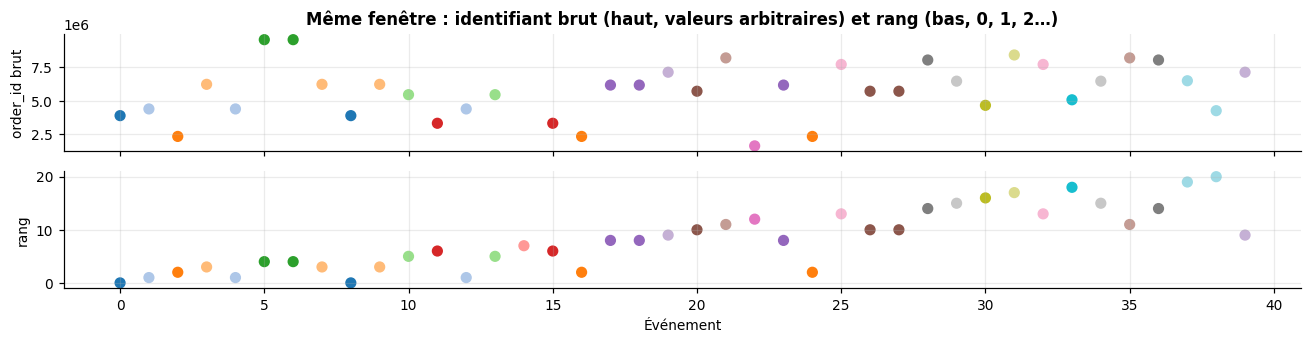

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(12, 3.2), sharex=True)
axs[0].scatter(w0.t, w0.order_id, c=w0['rank'], cmap='tab20', s=40); axs[0].set_ylabel('order_id brut')
axs[0].set_title("Même fenêtre : identifiant brut (haut, valeurs arbitraires) et rang (bas, 0, 1, 2…)")
axs[1].scatter(w0.t, w0['rank'], c=w0['rank'], cmap='tab20', s=40); axs[1].set_ylabel('rang'); axs[1].set_xlabel('Événement')
plt.tight_layout()

## 4. Parcours d'ordres

Avec le rang, on suit la vie de chaque ordre dans la fenêtre : la **combientième fois** il apparaît, son **action précédente**,
et le **nombre d'événements** écoulés depuis sa dernière apparition.

In [7]:
X['occ'] = X.groupby(['obs_id', 'rank']).cumcount()                                 # 0 = 1re apparition
X['prev_action'] = X.groupby(['obs_id', 'rank']).action.shift().fillna('—')         # action précédente du même ordre
X['gap'] = X.t - X.groupby(['obs_id', 'rank']).t.shift()                            # écart depuis la dernière apparition
w0 = X[X.obs_id == 0]
w0[['t', 'rank', 'action', 'occ', 'prev_action', 'gap']].head(14)

,t,rank,action,occ,prev_action,gap
0,0,0,A,0,—,NaN
1,1,1,A,0,—,NaN
2,2,2,A,0,—,NaN
3,3,3,A,0,—,NaN
4,4,1,U,1,A,3.0
5,5,4,A,0,—,NaN
6,6,4,D,1,A,1.0
7,7,3,U,1,A,4.0
8,8,0,D,1,A,8.0
9,9,3,D,2,U,2.0


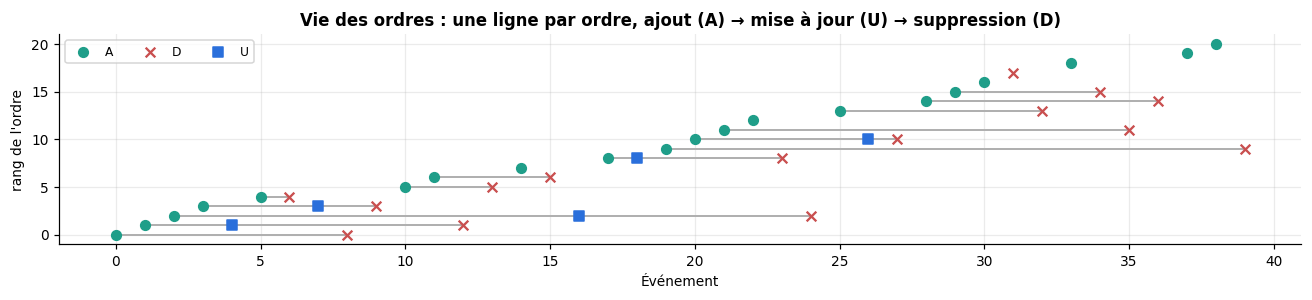

In [8]:
fig, ax = plt.subplots(figsize=(12, 2.8))
for r, g in w0.groupby('rank'):
    if len(g) > 1: ax.plot(g.t, [r] * len(g), color='#999', lw=1, zorder=1)
for a, m, c in [('A', 'o', '#1f9e89'), ('D', 'x', '#c94f4f'), ('U', 's', '#2a6fdb')]:
    e = w0[w0.action == a]; ax.scatter(e.t, e['rank'], marker=m, color=c, s=40, label=a, zorder=2)
ax.set_xlabel('Événement'); ax.set_ylabel("rang de l'ordre"); ax.legend(ncol=3, fontsize=8)
ax.set_title("Vie des ordres : une ligne par ordre, ajout (A) → mise à jour (U) → suppression (D)")
plt.tight_layout()

## 5. Tokens : chaque événement devient des petits entiers

Les seuils sont **fixés à l'avance** : ils ne sont appris sur aucune donnée, donc rien ne peut fuiter. L'indice 0 veut dire « inconnu ».

Événement 5 de la fenêtre 0 : {'action': 1, 'side': 2, 'pos': 4, 'size': 5, 'spread': 2, 'occ': 1, 'prev_action': 0}


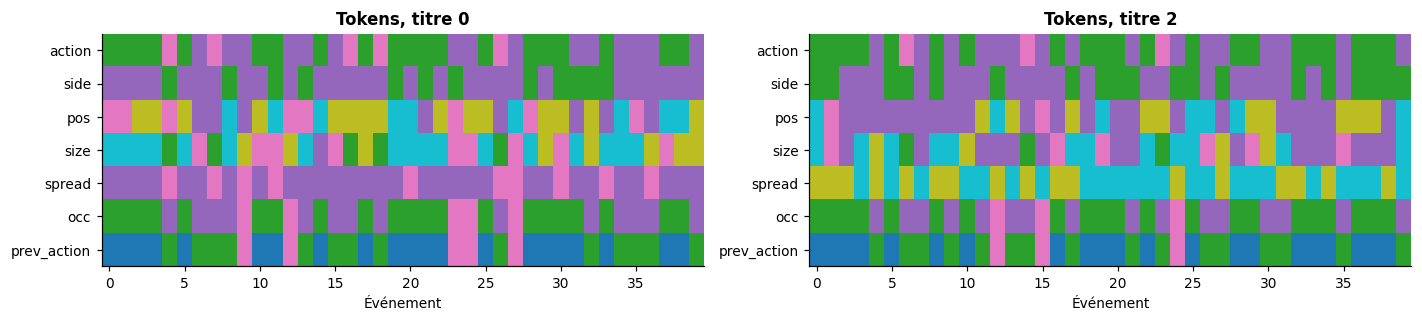

In [9]:
def bucket(x, edges):                      # 0 = NaN, puis 1, 2, … selon les seuils
    x = np.asarray(x, float)
    return np.where(np.isfinite(x), np.digitize(np.nan_to_num(x), edges) + 1, 0)

own_best = np.where(X.side == 'B', X.bid, X.ask)
X['dist_t'] = (np.where(X.side == 'B', own_best - X.price, X.price - own_best) / TICK).round()
TOK = pd.DataFrame({
    'action': X.action.map({'A': 1, 'D': 2, 'U': 3}),
    'side': X.side.map({'B': 1, 'S': 2}),
    'pos': bucket(X.dist_t, [-.5, .5, 1.5, 2.5, 5.5]),                  # dans le spread / au meilleur / 1 / 2 / 3-5 / >5
    'size': bucket(X.size_lots, [1e-9, 1 - 1e-9, 1 + 1e-9, 2 + 1e-9, 5 + 1e-9]),
    'spread': bucket(X.spread_t, [.5, 1.5, 2.5, 4.5]),                 # 0 / 1 / 2 / 3-4 / ≥5 ticks
    'occ': np.minimum(X.occ, 3) + 1,
    'prev_action': X.prev_action.map({'—': 0, 'A': 1, 'D': 2, 'U': 3}),
})
print('Événement 5 de la fenêtre 0 :', dict(TOK.iloc[5]))

fig, axs = plt.subplots(1, 2, figsize=(13, 3))
for ax, oid in zip(axs, [X[X.stock == 0].obs_id.min(), X[X.stock == 2].obs_id.min()]):
    T = TOK[X.obs_id.values == oid].T
    ax.imshow(T.values, aspect='auto', cmap='tab10', interpolation='nearest'); ax.grid(False)
    ax.set_yticks(range(len(T)), T.index); ax.set_xlabel('Événement')
    ax.set_title(f'Tokens, titre {X[X.obs_id == oid].stock.iloc[0]}')
plt.tight_layout()

## 6. Statistiques de fenêtre

On résume chaque fenêtre en une ligne : régime de spread, conventions de taille, profondeur, vie des ordres.

,stock,day,spread_1,spread_mean,odd_share,log_depth,repeat_share,split
obs_id,,,,,,,,
0,0,0,0.750,1.250,0.025,3.431242,0.475,train
1,0,0,0.775,1.225,0.075,3.459781,0.425,train
2,0,0,0.575,1.425,0.050,3.434471,0.500,train
3,0,0,0.675,1.325,0.150,3.358464,0.300,train
4,0,0,0.625,1.375,0.100,3.455843,0.450,train


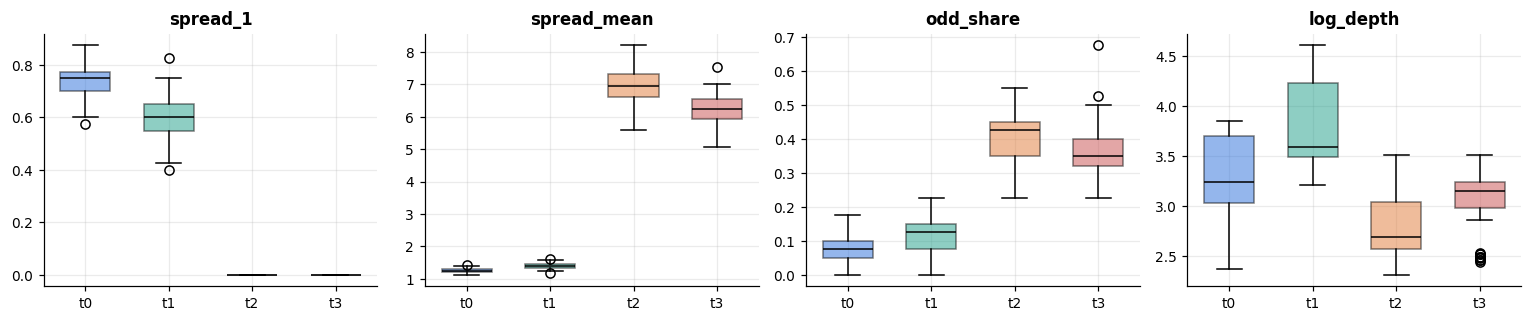

In [10]:
g = X.groupby('obs_id')
W = pd.DataFrame({
    'stock': g.stock.first(), 'day': g.day.first(),
    'spread_1': g.spread_t.apply(lambda s: (s == 1).mean()),          # part du temps à 1 tick
    'spread_mean': g.spread_t.mean(),
    'odd_share': g.odd.mean(),
    'log_depth': g.apply(lambda d: np.log1p(np.median(d.bid_size + d.ask_size) / LOT), include_groups=False),
    'repeat_share': g.occ.apply(lambda s: (s > 0).mean()),
})
W['split'] = np.where(W.day < 6, 'train', 'test')
fig, axs = plt.subplots(1, 4, figsize=(14, 3))
for ax, c in zip(axs, ['spread_1', 'spread_mean', 'odd_share', 'log_depth']):
    for s in STOCKS:
        ax.boxplot(W[W.stock == s][c], positions=[s], widths=.6, patch_artist=True,
                   boxprops=dict(facecolor=COL[s], alpha=.5), medianprops=dict(color='k'))
    ax.set_title(c); ax.set_xticks(range(4), [f't{s}' for s in STOCKS])
plt.tight_layout(); W.head()

## 7. Le piège du régime

On mesure deux choses par colonne :
- **l'utilité**, notée η², la part de la variance expliquée par le titre ;
- **la dérive**, notée KS, l'écart de distribution entre train et test.

Le spread en ticks est utile **et** stable. La profondeur est utile, mais **décalée** sur le test.

,eta2,ks
spread_1,0.977,0.062
spread_mean,0.983,0.117
odd_share,0.830,0.050
log_depth,0.516,0.221
repeat_share,0.012,0.046


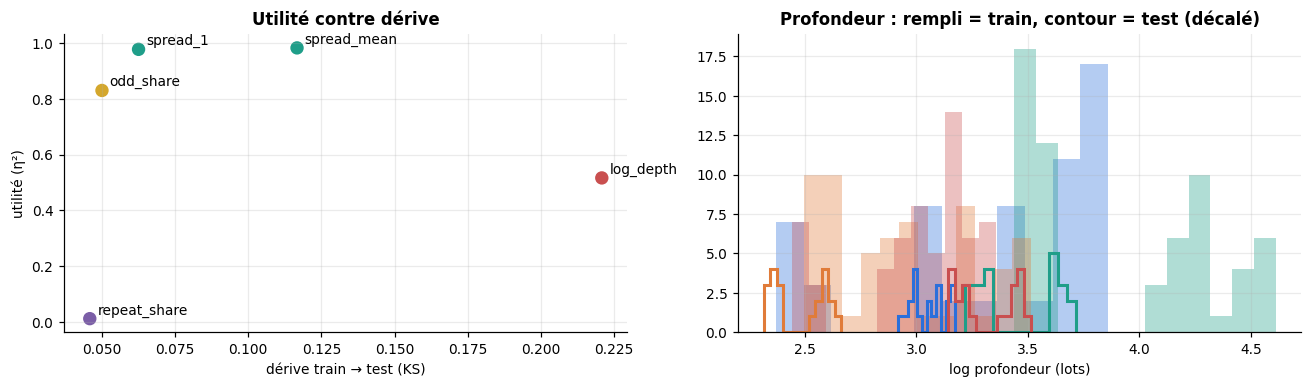

In [11]:
def eta2(x, y):
    m = x.mean(); return sum((x[y == c].mean() - m) ** 2 * (y == c).sum() for c in np.unique(y)) / ((x - m) ** 2).sum()
def ks(a, b):
    u = np.sort(np.r_[a, b]); return np.abs(np.searchsorted(np.sort(a), u, 'right') / len(a) - np.searchsorted(np.sort(b), u, 'right') / len(b)).max()

tr, te = W[W.split == 'train'], W[W.split == 'test']
cols = ['spread_1', 'spread_mean', 'odd_share', 'log_depth', 'repeat_share']
scr = pd.DataFrame({'eta2': [eta2(tr[c].values, tr.stock.values) for c in cols],
                    'ks': [ks(tr[c].values, te[c].values) for c in cols]}, index=cols)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
axs[0].scatter(scr.ks, scr.eta2, s=60, color=['#1f9e89', '#1f9e89', '#d4a72c', '#c94f4f', '#7b5ea7'])
for c, r in scr.iterrows(): axs[0].annotate(c, (r.ks, r.eta2), xytext=(5, 3), textcoords='offset points')
axs[0].set_xlabel('dérive train → test (KS)'); axs[0].set_ylabel('utilité (η²)'); axs[0].set_title('Utilité contre dérive')
for s in STOCKS:
    axs[1].hist(tr[tr.stock == s].log_depth, bins=12, alpha=.35, color=COL[s])
    axs[1].hist(te[te.stock == s].log_depth, bins=12, histtype='step', lw=2, color=COL[s])
axs[1].set_title('Profondeur : rempli = train, contour = test (décalé)'); axs[1].set_xlabel('log profondeur (lots)')
plt.tight_layout(); scr.round(3)

## 8. Validation aléatoire contre validation par jour

On prend un classifieur qui **mémorise** : le plus proche voisin (1-NN). C'est l'équivalent jouet d'un gros réseau. On le juge de deux façons :
- **aléatoire** : on mélange les fenêtres, donc des fenêtres du même jour se retrouvent des deux côtés ;
- **par jour** : on garde des jours entiers de côté, comme le vrai test.

Avec la profondeur, la plus proche voisine d'une fenêtre de validation est presque toujours une fenêtre **du même titre-jour**,
qui partage son régime. La validation aléatoire récompense donc la reconnaissance du jour. Sur des jours jamais vus, ce raccourci disparaît.

,aléatoire,par_jour,test
features,,,
"signature (ticks, lots)",0.729,0.725,0.738
+ régime (profondeur),0.896,0.700,0.750


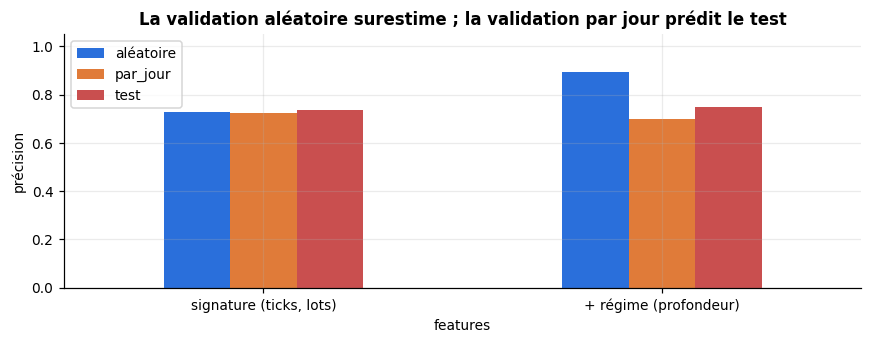

In [12]:
def zs(A, ref): return (A - ref.mean(0)) / (ref.std(0) + 1e-9)
def centroid_predict(Xtr, keys, ytr, Xte):                       # 1-NN : l'étiquette de la fenêtre d'entraînement la plus proche
    return ytr[((Xte[:, None] - Xtr[None]) ** 2).sum(-1).argmin(1)]

feats = {'signature (ticks, lots)': ['spread_1', 'spread_mean', 'odd_share'],
         '+ régime (profondeur)': ['spread_1', 'spread_mean', 'odd_share', 'log_depth']}
D = W[W.split == 'train'].reset_index(drop=True); y = D.stock.values; key = (D.stock * 100 + D.day).values
res = []
for name, cs in feats.items():
    A = D[cs].values
    idx = rng.permutation(len(D)); va = idx[:len(D) // 5]; fi = idx[len(D) // 5:]                        # aléatoire
    p = centroid_predict(zs(A[fi], A[fi]), key[fi], y[fi], zs(A[va], A[fi])); r_rand = (p == y[va]).mean()
    fi, va = np.where(D.day < 5)[0], np.where(D.day == 5)[0]                                           # par jour
    p = centroid_predict(zs(A[fi], A[fi]), key[fi], y[fi], zs(A[va], A[fi])); r_day = (p == y[va]).mean()
    T_ = W[W.split == 'test']; p = centroid_predict(zs(A, A), key, y, zs(T_[cs].values, A)); r_test = (p == T_.stock.values).mean()
    res.append(dict(features=name, aléatoire=r_rand, par_jour=r_day, test=r_test))
res = pd.DataFrame(res).set_index('features')
res.plot.bar(figsize=(8, 3.2), color=['#2a6fdb', '#e07b39', '#c94f4f'], rot=0)
plt.ylabel('précision'); plt.ylim(0, 1.05); plt.title('La validation aléatoire surestime ; la validation par jour prédit le test')
plt.tight_layout(); res.round(3)

## 9. Augmentation de profondeur

On multiplie les quantités affichées du carnet par un facteur exp(N(0 ; 0,3)), tiré **par fenêtre**. Le réseau apprend ainsi
qu'un même titre peut être plus ou moins profond. L'**imbalance** (bid − ask)/(bid + ask) ne change pas, car le même facteur multiplie les deux côtés.

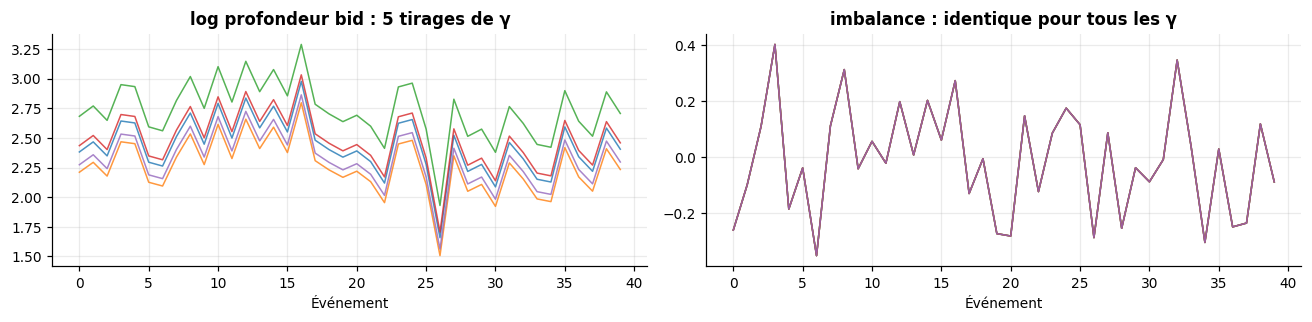

In [13]:
w = X[X.obs_id == 0]
gam = np.exp(rng.normal(0, .3, 5))
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
imb = lambda b, a: (b - a) / (b + a)
for gm in gam:
    axs[0].plot(w.t, np.log1p(gm * w.bid_size / LOT), lw=1, alpha=.8)
    axs[1].plot(w.t, imb(gm * w.bid_size, gm * w.ask_size), lw=1, alpha=.8)
axs[0].set_title('log profondeur bid : 5 tirages de γ'); axs[1].set_title('imbalance : identique pour tous les γ')
for a in axs: a.set_xlabel('Événement')
plt.tight_layout()

## 10. Sinkhorn : rééquilibrer les prédictions

Sur le test, un modèle **sur-prédit** les titres qui ressemblent au nouveau régime. Si l'on sait que le test est équilibré, on
cherche un poids par titre w_c tel que chaque titre reçoive 1/K des prédictions. On alterne : normaliser les lignes, puis rééchelonner les colonnes.

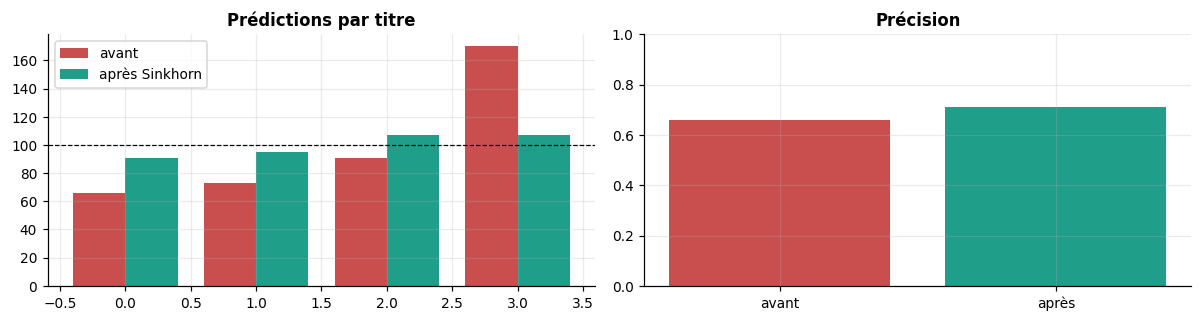

In [14]:
def sinkhorn(P, iters=50):
    Q = P.copy()
    for _ in range(iters):
        Q = Q / Q.sum(1, keepdims=True)                       # chaque fenêtre : une distribution
        Q = Q * (len(Q) / Q.shape[1]) / Q.sum(0)              # chaque titre : N/K de la masse
    return Q / Q.sum(1, keepdims=True)

K, N = 4, 400
ytrue = np.repeat(np.arange(K), N // K)
logits = rng.normal(0, 1, (N, K)); logits[np.arange(N), ytrue] += 1.6
logits[:, 3] += 1.0                                           # biais : le modèle sur-prédit le titre 3
P = np.exp(logits) / np.exp(logits).sum(1, keepdims=True); Q = sinkhorn(P)
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].bar(np.arange(K) - .2, np.bincount(P.argmax(1), minlength=K), .4, label='avant', color='#c94f4f')
axs[0].bar(np.arange(K) + .2, np.bincount(Q.argmax(1), minlength=K), .4, label='après Sinkhorn', color='#1f9e89')
axs[0].axhline(N / K, ls='--', color='k', lw=.8); axs[0].legend(); axs[0].set_title('Prédictions par titre')
axs[1].bar(['avant', 'après'], [(P.argmax(1) == ytrue).mean(), (Q.argmax(1) == ytrue).mean()], color=['#c94f4f', '#1f9e89'])
axs[1].set_ylim(0, 1); axs[1].set_title('Précision')
plt.tight_layout()

## 11. Vote entre voisins

Chaque fenêtre garde la moitié de son avis et prend l'autre moitié chez ses k voisines les plus proches : Q ← 0,5·P + 0,5·moyenne(Q des voisines),
répété 5 fois. Une fenêtre ambiguë, entourée de voisines nettes, est corrigée.

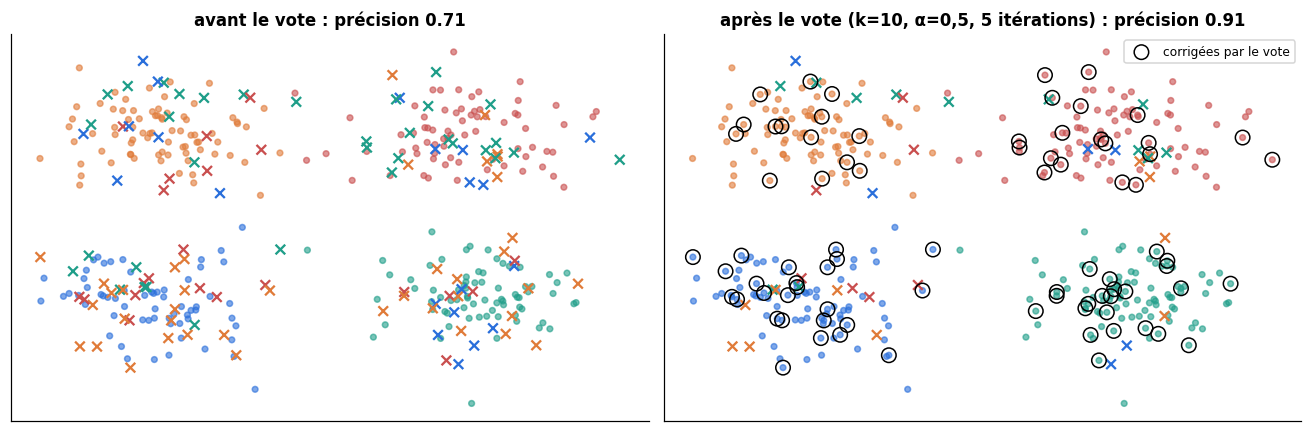

In [15]:
Z = rng.normal(0, 1, (N, 2)) * .55 + np.array([[0, 0], [3, 0], [0, 3], [3, 3]])[ytrue]   # représentation 2D jouet
Pn = np.exp(logits - 1.0 * (np.arange(K) == 3)) ; Pn = Pn / Pn.sum(1, keepdims=True)      # prédictions bruitées, sans le biais

def knn(Z, k):
    Zn = Z / np.linalg.norm(Z - Z.mean(0), axis=1, keepdims=True).clip(1e-9)
    d = ((Z[:, None] - Z[None]) ** 2).sum(-1); np.fill_diagonal(d, np.inf)
    return np.argsort(d, 1)[:, :k]

def smooth(P, nb, alpha=.5, iters=5):
    Q = P.copy()
    for _ in range(iters): Q = (1 - alpha) * P + alpha * Q[nb].mean(1)
    return Q

Qs = smooth(Pn, knn(Z, 10))
fixed = (Pn.argmax(1) != ytrue) & (Qs.argmax(1) == ytrue)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, M, t in [(axs[0], Pn, 'avant le vote'), (axs[1], Qs, 'après le vote (k=10, α=0,5, 5 itérations)')]:
    ok = M.argmax(1) == ytrue
    ax.scatter(*Z[ok].T, c=[COL[c] for c in M.argmax(1)[ok]], s=14, alpha=.6)
    ax.scatter(*Z[~ok].T, c=[COL[c] for c in M.argmax(1)[~ok]], s=40, marker='x')
    ax.set_title(f'{t} : précision {ok.mean():.2f}'); ax.set_xticks([]); ax.set_yticks([])
axs[1].scatter(*Z[fixed].T, s=90, facecolors='none', edgecolors='k', lw=1, label='corrigées par le vote'); axs[1].legend(fontsize=8)
plt.tight_layout()

## 12. Pseudo-labels : filtre d'accord + quota, contre un simple seuil

Un **seuil de confiance** retient surtout les titres faciles : les pseudo-labels héritent du biais du professeur. Le **quota** prend
le même nombre de fenêtres par titre prédit, parmi celles où les deux lectures du professeur (brute et lissée) **concordent**.

professeur : précision brute 0.66, lissée 0.73


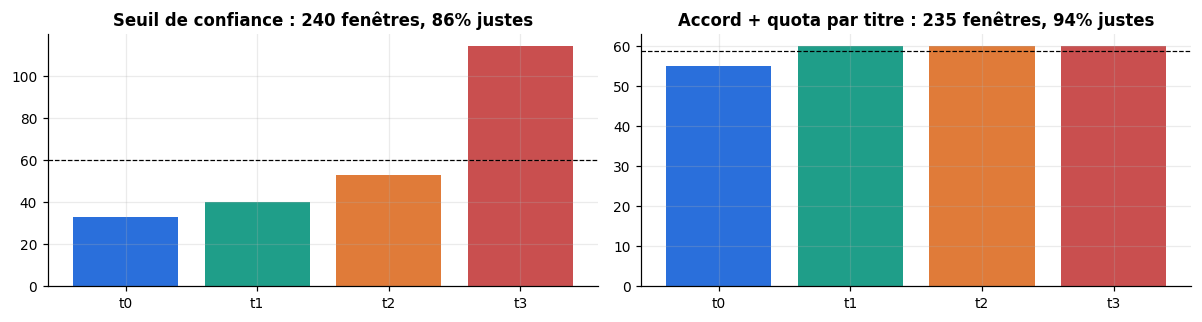

In [16]:
# professeur imparfait : il sur-prédit le titre 3 (le biais du §10) ; deux lectures, brute et lissée par les voisins
raw = P; smooth_ = smooth(P, knn(Z, 3), alpha=.3, iters=1)
conf, pred = smooth_.max(1), smooth_.argmax(1)
print(f'professeur : précision brute {(raw.argmax(1) == ytrue).mean():.2f}, lissée {(pred == ytrue).mean():.2f}')
by_threshold = np.where(conf >= np.quantile(conf, .4))[0]                      # 60 % les plus confiantes
agree = pred == raw.argmax(1); quota = int(.6 * N / K)
by_quota = np.concatenate([np.where(agree & (pred == c))[0][np.argsort(-conf[agree & (pred == c)])][:quota] for c in range(K)])
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
for ax, sel, t in [(axs[0], by_threshold, 'Seuil de confiance'), (axs[1], by_quota, "Accord + quota par titre")]:
    ax.bar(range(K), np.bincount(pred[sel], minlength=K), color=COL)
    ax.set_title(f'{t} : {len(sel)} fenêtres, {(pred[sel] == ytrue[sel]).mean():.0%} justes'); ax.axhline(len(sel) / K, ls='--', color='k', lw=.8); ax.set_xticks(range(K), [f't{c}' for c in range(K)])
plt.tight_layout()

## En résumé

| Transformation | Ce qu'elle corrige |
|---|---|
| Ticks et lots | la normalisation locale qui effaçait la signature du titre |
| Rang de première apparition | un identifiant traité comme un nombre arbitraire |
| Tokens et parcours d'ordres | des seuils appris, et une vie des ordres invisible |
| Validation par jour | une validation qui récompense la mémorisation du jour |
| Augmentation de profondeur | un modèle qui dépend du niveau de profondeur d'une période |
| Sinkhorn | un biais de prédiction vers certains titres |
| Vote entre voisins | des fenêtres ambiguës isolées |
| Accord + quota | des pseudo-labels biaisés vers les titres faciles |